# 3 · plot — Helico structure accuracy

Draws [`3_make_gdt_ts_data.ipynb`](3_make_gdt_ts_data.ipynb)'s table, one panel per protein class.

**The two panels do not say the same thing.** On natural monomers MarinFold's contacts take Helico
from ~0.15 to ~0.48 GDT-TS, against ~0.17 for Protenix-v2 in single-sequence mode. On the 19
designed monomers they take it *down* — below `Helico, no contacts` — because designed backbones
are idealised, single-sequence predictors already handle them, and imperfect contacts subtract.
Any caption written over these panels has to survive that.

In [1]:
# Run from anywhere: figlib lives next to this notebook.
import sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "figlib.py").exists() else Path("notebooks/figures")
sys.path.insert(0, str(HERE.resolve()))
import figlib

In [2]:
DATASET = "3_gdt_ts"
DPI = 300
# arm -> label. `mf_L2` / `mf_L5` (the top-L/2 and top-L/5 contact budgets) are in the dataset
# and left out of the figure by default.
ARMS = {
    "protenix_v2_msa": "Protenix-v2 + MSA",
    "esmfold2": "ESMFold2",
    "oracle": "Helico + true contacts",
    "mf_L": "Helico + MarinFold contacts",
    "protenix_v2_single_seq": "Protenix-v2, single sequence",
    "off": "Helico, no contacts",
}
HIGHLIGHT = "mf_L"
metadata = figlib.describe(DATASET)

dataset      3_gdt_ts
made by      3_make_gdt_ts_data.ipynb
generated    2026-08-21T15:31:37+00:00
machine      ip1 · python 3.11.14 · NVIDIA RTX A5000 (23.7 GiB, cc 8.6)
checkout     e9fd3f0507df on exp250/evals-exploration-notebook  ** UNCOMMITTED CHANGES **
packages     marinfold 0.1.0, torch 2.5.1+cu121, transformers 4.57.6, numpy 2.4.6, pandas 3.0.5, matplotlib 3.11.1

parameters
   metric                   gdt_ts
   classes                  ['natural', 'designed']
   bootstrap_draws          2000
   bootstrap_seed           0

inputs
   f79ea0842e9a        494,323 B  https://huggingface.co/buckets/timodonnell/helico-experiments/resolve/exp14_foldbench_held_out_monomers/scores/per_target.csv

outputs
   8916259d7ac3          1,749 B  summary.csv
   e3a4a00280be        484,463 B  per_target.csv


--- designed · n=19 proteins ---


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/gdt_ts_designed.png (300 dpi) and gdt_ts_designed.pdf


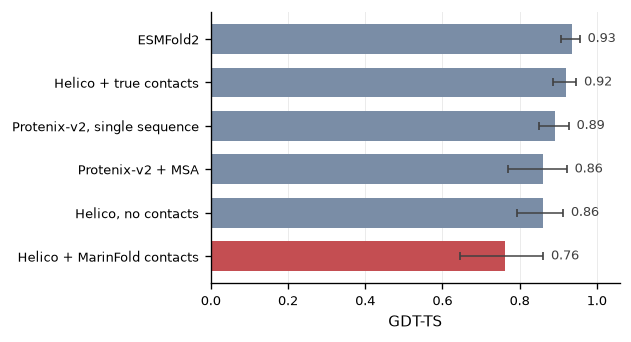

                       label  n  value  ci_low  ci_high
 Helico + MarinFold contacts 19  0.761   0.647    0.861
         Helico, no contacts 19  0.859   0.793    0.913
           Protenix-v2 + MSA 19  0.860   0.771    0.923
Protenix-v2, single sequence 19  0.892   0.851    0.928
      Helico + true contacts 19  0.920   0.886    0.947
                    ESMFold2 19  0.934   0.908    0.956
--- natural · n=305 proteins ---


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/gdt_ts_natural.png (300 dpi) and gdt_ts_natural.pdf


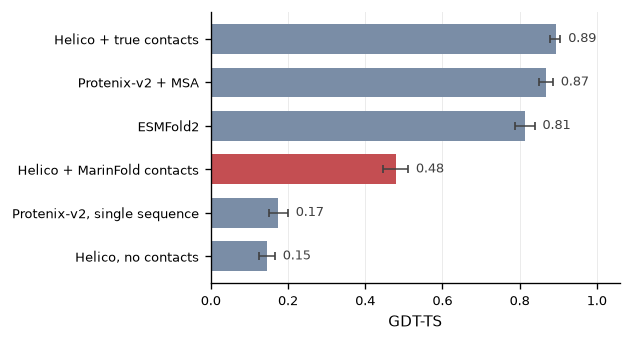

                       label   n  value  ci_low  ci_high
         Helico, no contacts 305  0.146   0.124    0.166
Protenix-v2, single sequence 305  0.174   0.150    0.200
 Helico + MarinFold contacts 305  0.479   0.445    0.511
                    ESMFold2 305  0.814   0.787    0.839
           Protenix-v2 + MSA 305  0.868   0.850    0.887
      Helico + true contacts 305  0.893   0.878    0.906


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

figlib.figure_style(DPI)
summary = pd.read_csv(figlib.dataset_dir(DATASET) / "summary.csv")
ACCENT, NEUTRAL = "#C44E52", "#7A8DA6"

for protein_class in summary.protein_class.unique():
    frame = summary[(summary.protein_class == protein_class) & summary.arm.isin(ARMS)].copy()
    frame["label"] = frame.arm.map(ARMS)
    frame = frame.sort_values("value")
    figure, axis = plt.subplots(figsize=(4.4, 0.34 * len(frame) + 0.9))
    axis.barh(frame.label, frame.value, height=0.68,
              color=[ACCENT if arm == HIGHLIGHT else NEUTRAL for arm in frame.arm],
              xerr=[frame.value - frame.ci_low, frame.ci_high - frame.value],
              error_kw=dict(ecolor="0.25", lw=0.9, capsize=2.5))
    for y, row in enumerate(frame.itertuples()):
        axis.text(row.ci_high + 0.02, y, f"{row.value:.2f}", va="center", fontsize=7.5,
                  color="0.25")
    axis.set(xlabel="GDT-TS", xlim=(0, 1.06))
    axis.grid(axis="x", alpha=0.25, lw=0.6)
    axis.set_axisbelow(True)
    print(f"--- {protein_class} · n={int(frame.n.iloc[0])} proteins ---")
    figlib.save_figure(figure, f"gdt_ts_{protein_class}", DPI)
    plt.show()
    print(frame[["label", "n", "value", "ci_low", "ci_high"]]
          .to_string(index=False, float_format=lambda v: f"{v:.3f}"))